# Double Demeaning for Fixed Effects Interactions: Python Implementation

This notebook implements the double demeaning technique for proper estimation of interactions in fixed effects regression models, as described in:

**Giesselmann, M., & Schmidt-Catran, A. W. (2022). Interactions in Fixed Effects Regression Models. *Sociological Methods & Research*, 51(3), 1100-1127.**

## Background and Motivation

### The Problem
In standard fixed effects (FE) regression, interactions are typically specified by demeaning the product term. However, this approach does **not** yield a true within-unit estimator. Instead, it reflects unit-level differences of the interacted variables.

### The Solution: Double Demeaning
A proper within-unit estimator of interactions can be obtained by:
1. **First** demeaning each variable individually (within units)
2. **Then** creating the interaction from these demeaned variables

This "double-demeaned" estimator:
- Is not subject to bias from unobserved effect heterogeneity
- Provides a true within-unit interaction effect
- Requires T > 2 (more than 2 time periods)
- May be less efficient than standard FE but is unbiased

## Setup and Dependencies


In [12]:
# Required packages (install once if needed):
# pip install dd-ie

import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from linearmodels import PanelOLS

# For production use, import directly from the installed package:
# from dd_ie import DoubleDemeanAnalysis
#
# This tutorial re-implements the algorithm step-by-step for educational purposes.

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")
print(f"pandas {pd.__version__}, numpy {np.__version__}")


pandas 2.2.3, numpy 2.4.1


## Step 1: Data Loading and Setup

We'll use the same example as in the original Stata code - infant birth weight data to estimate the interaction between smoking behavior and maternal age on birthweight.


In [13]:
# Load the smoking dataset (Abrevaya 2006, used in Giesselmann & Schmidt-Catran 2022)
#
# Download smoking.dta from:
#   https://www.stata-press.com/data/mlmus2/smoking.dta
# and place it in the same folder as this notebook.

try:
    df = pd.read_stata("smoking.dta")
    print(f"Loaded {len(df):,} observations, {df['momid'].nunique():,} mothers")
except FileNotFoundError:
    print("smoking.dta not found.")
    print("Download from: https://www.stata-press.com/data/mlmus2/smoking.dta")
    print("Place in the same folder as this notebook, then re-run this cell.")
    raise

df.head()


Loaded 8,604 observations, 3,978 mothers


,momid,idx,stateres,mage,meduc,mplbir,nlbnl,gestat,birwt,cigs,...,hsgrad,somecoll,collgrad,magesq,black,kessner2,kessner3,novisit,pretri2,pretri3
0,14.0,1.0,AL,16.0,10.0,VA,0.0,24.0,2790.0,0.0,...,0.0,0.0,0.0,256.0,Black,0.0,1.0,0.0,0.0,1.0
1,14.0,2.0,AL,17.0,10.0,VA,1.0,42.0,2693.0,0.0,...,0.0,0.0,0.0,289.0,Black,0.0,1.0,0.0,0.0,1.0
2,14.0,3.0,AL,20.0,10.0,VA,2.0,39.0,3600.0,0.0,...,0.0,0.0,0.0,400.0,Black,0.0,0.0,0.0,0.0,0.0
3,25.0,1.0,AL,23.0,11.0,NJ,2.0,41.0,2778.0,0.0,...,0.0,0.0,0.0,529.0,Black,1.0,0.0,0.0,1.0,0.0
4,25.0,2.0,AL,24.0,11.0,NJ,3.0,37.0,2835.0,0.0,...,0.0,0.0,0.0,576.0,Black,1.0,0.0,0.0,1.0,0.0


## Step 2: Define Variables and Set Panel Structure

Following the original Stata code structure, we define our key variables:


In [14]:
# Define variables (matching original Stata code)
unit_var = 'momid'      # Unit identifier (i)
time_var = 'idx'        # Time identifier (t) 
y_var = 'birwt'         # Dependent variable
x_var = 'mage'          # First time-varying interactor
z_var = 'smoke'         # Second time-varying interactor
w_vars = ['married']    # Covariates

print(f"Panel structure:")
print(f"  Unit variable: {unit_var}")
print(f"  Time variable: {time_var}")
print(f"  Dependent variable: {y_var}")
print(f"  Interactors: {x_var} × {z_var}")
print(f"  Covariates: {w_vars}")

# Check data types and convert if necessary
print(f"\nData types before conversion:")
analysis_vars = [y_var, x_var, z_var] + w_vars
for var in analysis_vars:
    print(f"  {var}: {df[var].dtype}")

# Convert categorical variables to numeric where appropriate
for var in analysis_vars:
    if df[var].dtype.name == 'category':
        if df[var].cat.categories.dtype in ['int64', 'float64']:
            # Categories are numeric, convert to numeric
            df[var] = df[var].astype(float)
            print(f"  Converted {var} from category to float")
        else:
            # Categories are strings, convert to codes
            df[var] = df[var].cat.codes.astype(float)
            print(f"  Converted {var} from category to numeric codes")
    elif df[var].dtype == 'object':
        # Try to convert object to numeric
        try:
            df[var] = pd.to_numeric(df[var])
            print(f"  Converted {var} from object to numeric")
        except:
            print(f"  Warning: Could not convert {var} to numeric")

# Set panel structure
df = df.set_index([unit_var, time_var])
print(f"\nPanel data structure set with MultiIndex: {df.index.names}")

# Basic descriptive statistics
print("\nDescriptive Statistics:")
print(df[[y_var, x_var, z_var] + w_vars].describe())


Panel structure:
  Unit variable: momid
  Time variable: idx
  Dependent variable: birwt
  Interactors: mage × smoke
  Covariates: ['married']

Data types before conversion:
  birwt: float32
  mage: float32
  smoke: category
  married: float32
  Converted smoke from category to numeric codes

Panel data structure set with MultiIndex: ['momid', 'idx']

Descriptive Statistics:
             birwt         mage        smoke      married
count  8604.000000  8604.000000  8604.000000  8604.000000
mean   3469.931152    28.591818     0.139935     0.886681
std     527.139404     5.485692     0.346940     0.317001
min     284.000000    14.000000     0.000000     0.000000
25%    3147.000000    24.000000     0.000000     1.000000
50%    3486.500000    29.000000     0.000000     1.000000
75%    3799.000000    33.000000     0.000000     1.000000
max    5642.000000    45.000000     1.000000     1.000000


## Step 3: The Core Innovation - Double Demeaning Implementation

This is the key contribution of Giesselmann & Schmidt-Catran (2022): creating a proper within-unit interaction estimator through double demeaning.


In [15]:
def create_double_demeaned_interaction(df, x_var, z_var, unit_var):
    """
    Create double demeaned interaction term (Giesselmann & Schmidt-Catran 2022).

    Demeans each variable within units, then forms the interaction from the
    demeaned variables, providing an unbiased within-unit interaction estimator.

    Adds columns: mean_{var}, dm_{var}, int_{x}_{z}, dd_int_{x}_{z}.
    """
    df_dd = df.copy()
    for var in [x_var, z_var]:
        df_dd[f"mean_{var}"] = df_dd.groupby(level=0)[var].transform("mean")
        df_dd[f"dm_{var}"]   = df_dd[var] - df_dd[f"mean_{var}"]
    interaction_name = f"int_{x_var}_{z_var}"
    df_dd[interaction_name]         = df_dd[x_var] * df_dd[z_var]
    df_dd[f"dd_{interaction_name}"] = df_dd[f"dm_{x_var}"] * df_dd[f"dm_{z_var}"]
    return df_dd


# Grand mean centering (matching Stata's preprocessing order)
df_centered = df.copy()
for var in [y_var, x_var, z_var] + w_vars:
    if var in df_centered.columns:
        df_centered[var] = df_centered[var] - df_centered[var].mean()
print("Grand mean centering applied.")

# Create double demeaned variables
df_double_demeaned = create_double_demeaned_interaction(df_centered, x_var, z_var, unit_var)
print("Double demeaned interaction created.")


Grand mean centering applied.
Double demeaned interaction created.


## Step 4: Fixed Effects Estimation and Comparison

Now we estimate both the standard FE model and the double demeaned FE model to compare results.


In [16]:
def estimate_fe_models_and_compare(df, y_var, x_var, z_var, w_vars):
    """
    Estimate standard FE and double demeaned FE models and compare coefficients.

    Returns (standard_results, dd_results, comparison_df).
    """
    # Keep only control variables with within-unit variation
    within_std = df.groupby(level=0)[w_vars].std().fillna(0)
    valid_w_vars = [v for v in w_vars if (within_std[v] > 0).mean() >= 0.05]
    excluded = set(w_vars) - set(valid_w_vars)
    if excluded:
        print(f"Note: {excluded} excluded - insufficient within-unit variation.")
    w_vars = valid_w_vars

    # Standard FE model
    interaction_name = f"int_{x_var}_{z_var}"
    df[interaction_name] = df[x_var] * df[z_var]
    standard_vars = [x_var, z_var, interaction_name] + w_vars
    standard_results = (
        PanelOLS(df[y_var], df[standard_vars], entity_effects=True)
        .fit(cov_type="clustered", cluster_entity=True)
    )

    # Double demeaned FE model
    dd_interaction_name = f"dd_int_{x_var}_{z_var}"
    dd_vars = [x_var, z_var, dd_interaction_name] + w_vars
    dd_results = (
        PanelOLS(df[y_var], df[dd_vars], entity_effects=True)
        .fit(cov_type="clustered", cluster_entity=True)
    )

    # Coefficient comparison table
    rows = []
    for var in standard_results.params.index:
        dd_var = dd_interaction_name if var == interaction_name else var
        if dd_var in dd_results.params.index:
            rows.append({
                "Variable":           "interaction" if var == interaction_name else var,
                "Standard_FE_Coef":   standard_results.params[var],
                "Standard_FE_SE":     standard_results.std_errors[var],
                "DoubleDemean_Coef":  dd_results.params[dd_var],
                "DoubleDemean_SE":    dd_results.std_errors[dd_var],
                "Difference":         dd_results.params[dd_var] - standard_results.params[var],
            })
    comparison_df = pd.DataFrame(rows)

    print("\nStandard FE results:")
    print(standard_results.summary.tables[1])
    print("\nDouble Demeaned FE results:")
    print(dd_results.summary.tables[1])
    print("\nCoefficient comparison (Double Demeaned - Standard FE):")
    print(comparison_df.to_string(index=False))

    return standard_results, dd_results, comparison_df


standard_results, dd_results, comparison_df = estimate_fe_models_and_compare(
    df_double_demeaned, y_var, x_var, z_var, w_vars
)


Note: {'married'} excluded - insufficient within-unit variation.

Standard FE results:
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
mage               23.282     3.1385     7.4182     0.0000      17.129      29.435
smoke             -97.167     34.769    -2.7946     0.0052     -165.33     -29.003
int_mage_smoke     3.7946     5.1575     0.7357     0.4619     -6.3166      13.906

Double Demeaned FE results:
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
mage                  23.124     3.1253     7.3991     0.0000      16.997      29.252
smoke                -102.59     31.811   

## Step 5: Complete Implementation Function

Here's a comprehensive function that combines all steps for easy application to your own data:


In [17]:
def perform_hausman_test(standard_results, dd_results, x_var, z_var):
    """
    Hausman test for systematic differences between standard FE and double demeaned FE.

    Re-estimates both models with unadjusted covariance to match Stata's hausman command.
    H0: No systematic difference between estimators.
    """
    from scipy import stats

    interaction_var    = f"int_{x_var}_{z_var}"
    dd_interaction_var = f"dd_int_{x_var}_{z_var}"

    std_unadj = standard_results.model.fit(cov_type="unadjusted", debiased=True)
    dd_unadj  = dd_results.model.fit(cov_type="unadjusted",       debiased=True)

    var_map     = {v: (dd_interaction_var if v == interaction_var else v)
                   for v in std_unadj.params.index}
    common_vars = [v for v, dv in var_map.items() if dv in dd_unadj.params.index]
    dd_common   = [var_map[v] for v in common_vars]

    b_std  = np.array([std_unadj.params[v] for v in common_vars])
    b_dd   = np.array([dd_unadj.params[v]  for v in dd_common])
    V_std  = std_unadj.cov.loc[common_vars, common_vars].values
    V_dd   = dd_unadj.cov.loc[dd_common, dd_common].values
    diff   = b_dd - b_std
    V_diff = V_dd - V_std

    pos_def = bool(np.all(np.linalg.eigvals(V_diff) > 1e-10))
    try:
        V_inv        = np.linalg.inv(V_diff) if pos_def else np.linalg.pinv(V_diff, rcond=1e-10)
        hausman_stat = float(diff @ V_inv @ diff)
    except np.linalg.LinAlgError:
        print("Cannot compute Hausman statistic - numerical issues.")
        return None

    df_dof  = len(common_vars)
    p_value = 1 - stats.chi2.cdf(hausman_stat, df=df_dof)

    print(f"\nHausman test  chi2({df_dof}) = {hausman_stat:.2f},  Prob > chi2 = {p_value:.4f}")
    if not pos_def:
        print("  (V_b - V_B is not positive definite; generalized inverse used)")
    conclusion = "SYSTEMATIC BIAS DETECTED" if p_value < 0.05 else "NO SYSTEMATIC BIAS"
    print(f"  Conclusion: {conclusion}")

    return {
        "hausman_statistic":  hausman_stat,
        "p_value":            p_value,
        "degrees_of_freedom": df_dof,
        "conclusion":         conclusion,
        "positive_definite":  pos_def,
    }


def double_demean_analysis(df, unit_var, time_var, y_var, x_var, z_var,
                           w_vars=None, center_variables=True, run_hausman=True):
    """
    Complete double demeaning analysis for fixed effects interactions.

    Implements Giesselmann & Schmidt-Catran (2022): grand mean centering,
    within-unit demeaning, FE estimation, and optional Hausman test.

    Returns a dict with keys: standard_results, dd_results, comparison_df,
    hausman_test, data_processed, panel_info.
    """
    if w_vars is None:
        w_vars = []
    df_work    = df.set_index([unit_var, time_var]).copy()
    panel_info = df_work.groupby(level=0).size()
    print(f"Panel: {len(panel_info)} units, "
          f"{panel_info.min()}-{panel_info.max()} periods per unit")

    if center_variables:
        for var in [y_var, x_var, z_var] + w_vars:
            if var in df_work.columns:
                df_work[var] -= df_work[var].mean()
        print("Grand mean centering applied.")

    df_dd = create_double_demeaned_interaction(df_work, x_var, z_var, unit_var)
    std_res, dd_res, comp_df = estimate_fe_models_and_compare(
        df_dd, y_var, x_var, z_var, w_vars
    )
    hausman = perform_hausman_test(std_res, dd_res, x_var, z_var) if run_hausman else None

    return {
        "standard_results": std_res,
        "dd_results":       dd_res,
        "comparison_df":    comp_df,
        "hausman_test":     hausman,
        "data_processed":   df_dd,
        "panel_info": {
            "n_units":      len(panel_info),
            "min_periods":  int(panel_info.min()),
            "max_periods":  int(panel_info.max()),
            "mean_periods": float(panel_info.mean()),
        },
    }


complete_results = double_demean_analysis(
    df=df.reset_index(),
    unit_var=unit_var,
    time_var=time_var,
    y_var=y_var,
    x_var=x_var,
    z_var=z_var,
    w_vars=w_vars,
    center_variables=True,
    run_hausman=True,
)


Panel: 3978 units, 2-3 periods per unit
Grand mean centering applied.
Note: {'married'} excluded - insufficient within-unit variation.

Standard FE results:
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
mage               23.282     3.1385     7.4182     0.0000      17.129      29.435
smoke             -97.167     34.769    -2.7946     0.0052     -165.33     -29.003
int_mage_smoke     3.7946     5.1575     0.7357     0.4619     -6.3166      13.906

Double Demeaned FE results:
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
mage                  23.124     3.1253     7.3991     0.0

## Step 6: Visualization Functions

Let's create some visualizations to better understand the differences between the two approaches:


In [ ]:
def plot_interaction_comparison(comparison_df, df_processed, x_var, z_var):
    """
    Create visualizations comparing the two estimation approaches.
    
    Parameters:
    -----------
    comparison_df : pandas.DataFrame
        Results from model comparison
    df_processed : pandas.DataFrame
        Processed data with demeaned variables
    x_var, z_var : str
        Names of interacting variables
    """
    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Double Demeaning vs Standard Fixed Effects: Comparison', fontsize=16, fontweight='bold')
    
    # Plot 1: Coefficient comparison
    valid_rows = comparison_df.dropna(subset=['Standard_FE_Coef', 'DoubleDemean_Coef'])
    
    ax1.scatter(valid_rows['Standard_FE_Coef'], valid_rows['DoubleDemean_Coef'], 
               alpha=0.7, s=100, color='steelblue')
    
    # Add diagonal line (y = x)
    min_val = min(valid_rows['Standard_FE_Coef'].min(), valid_rows['DoubleDemean_Coef'].min())
    max_val = max(valid_rows['Standard_FE_Coef'].max(), valid_rows['DoubleDemean_Coef'].max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    # Highlight interaction coefficient
    interaction_row = valid_rows[valid_rows['Variable'] == 'interaction']
    if not interaction_row.empty:
        ax1.scatter(interaction_row['Standard_FE_Coef'], interaction_row['DoubleDemean_Coef'], 
                   s=200, color='red', marker='D', label=f'Interaction', zorder=5)
        ax1.legend()
    
    ax1.set_xlabel('Standard FE Coefficients')
    ax1.set_ylabel('Double Demeaned Coefficients')
    ax1.set_title('Coefficient Comparison\\n(Points on diagonal = identical estimates)')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Coefficient differences
    colors = ['red' if var == 'interaction' else 'skyblue' for var in valid_rows['Variable']]
    
    bars = ax2.bar(range(len(valid_rows)), valid_rows['Difference'], color=colors, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.set_xlabel('Variables')
    ax2.set_ylabel('Coefficient Difference\\n(Double Demeaned - Standard FE)')
    ax2.set_title('Coefficient Differences by Variable')
    ax2.set_xticks(range(len(valid_rows)))
    ax2.set_xticklabels([var[:8] + '...' if len(var) > 8 else var for var in valid_rows['Variable']], 
                       rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Distribution of demeaned variables
    df_plot = df_processed.reset_index()
    ax3.hist(df_plot[x_var], alpha=0.6, bins=30, label=f'Original {x_var}', color='blue', density=True)
    ax3.hist(df_plot[f'dm_{x_var}'], alpha=0.6, bins=30, label=f'Demeaned {x_var}', color='red', density=True)
    ax3.set_xlabel(f'{x_var} values')
    ax3.set_ylabel('Density')
    ax3.set_title(f'{x_var}: Original vs Demeaned Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Interaction terms comparison
    interaction_std = f'int_{x_var}_{z_var}'
    interaction_dd = f'dd_int_{x_var}_{z_var}'
    
    ax4.scatter(df_plot[interaction_std], df_plot[interaction_dd], alpha=0.5, s=20)
    
    # Add diagonal line
    min_int = min(df_plot[interaction_std].min(), df_plot[interaction_dd].min())
    max_int = max(df_plot[interaction_std].max(), df_plot[interaction_dd].max())
    ax4.plot([min_int, max_int], [min_int, max_int], 'r--', alpha=0.8, linewidth=2)
    
    ax4.set_xlabel('Standard Interaction Term')
    ax4.set_ylabel('Double Demeaned Interaction Term')
    ax4.set_title('Interaction Terms: Standard vs Double Demeaned')
    ax4.grid(True, alpha=0.3)
    
    # Add correlation info
    correlation = df_plot[interaction_std].corr(df_plot[interaction_dd])
    ax4.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=ax4.transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

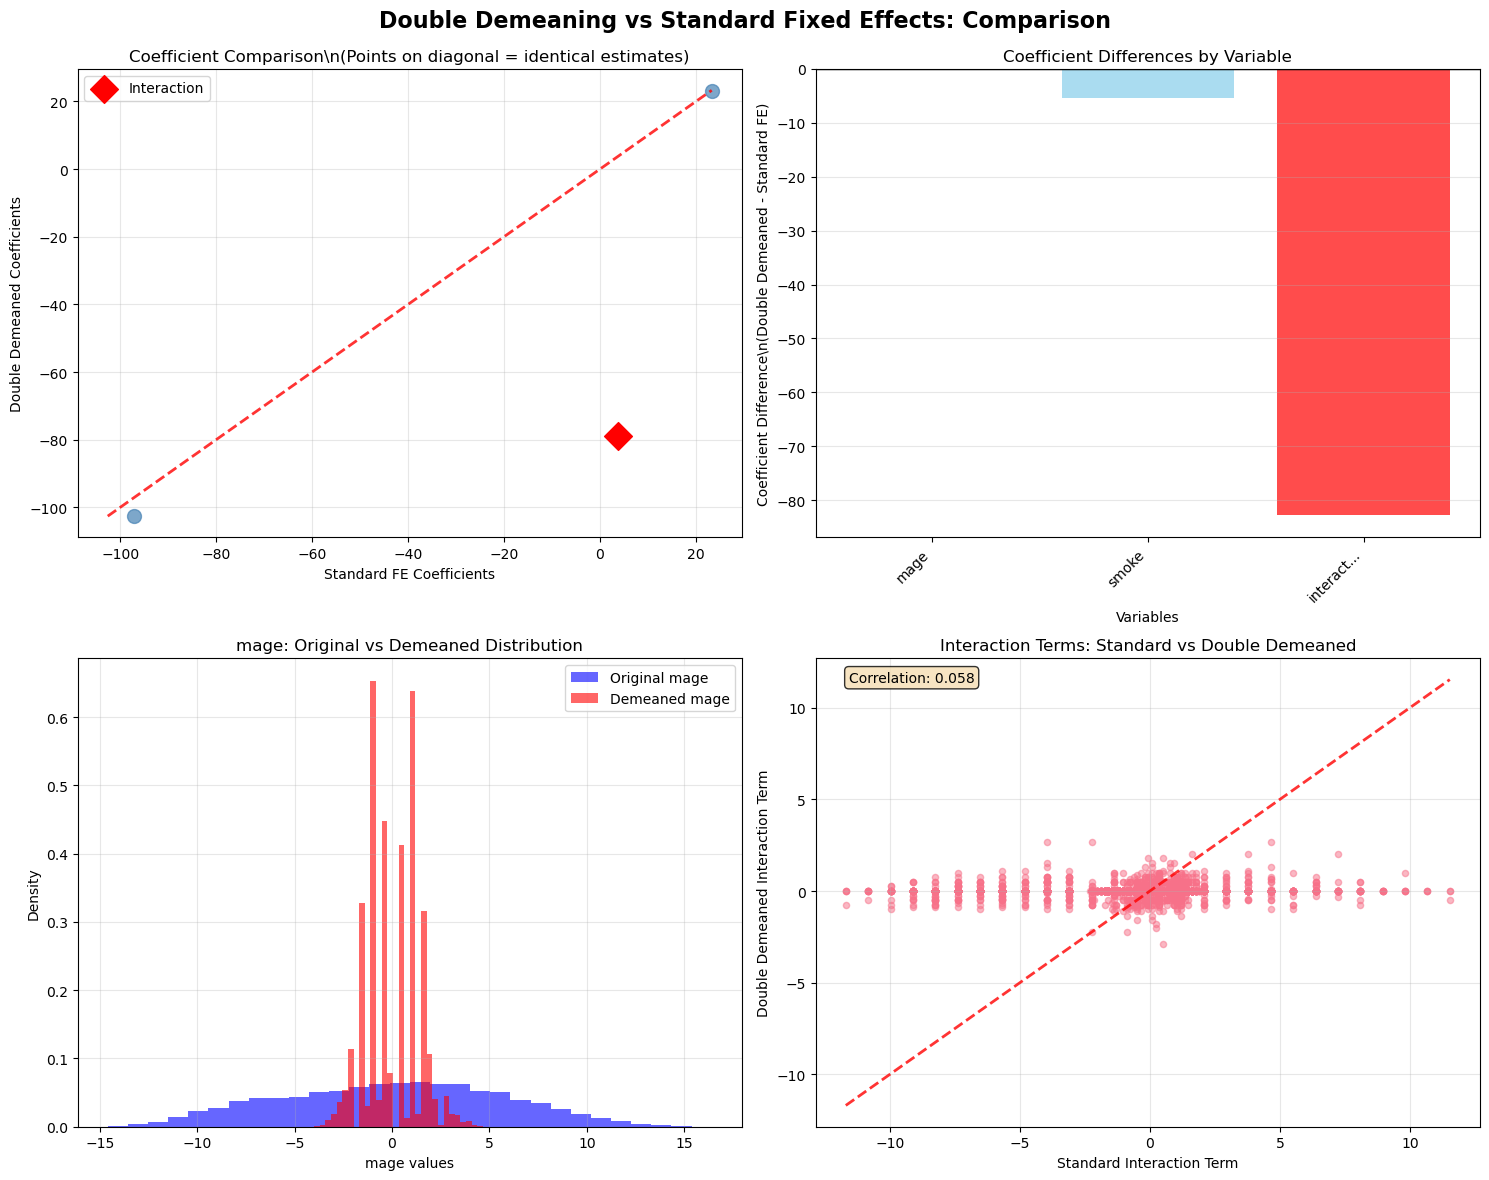

In [ ]:
plot_interaction_comparison(comparison_df, df_double_demeaned, x_var, z_var)